## Setup

In [27]:
import os
import json
import asyncio
import nest_asyncio
from IPython.display import Image, display
from dotenv import load_dotenv
from utils import chat_interface
from typing import Annotated, Optional, Literal, List, Dict, TypedDict
from pydantic import BaseModel, EmailStr, Field

from langchain_mcp_adapters.client import MultiServerMCPClient
from langgraph.graph.message import MessagesState, add_messages
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnableConfig
from langchain.agents import create_agent
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import START, END, StateGraph
from langgraph.graph.state import CompiledStateGraph
from langgraph.types import Command

from langchain_openai import ChatOpenAI, OpenAIEmbeddings

from langchain_tavily import TavilySearch

# import agentic.tools.tools as tools
# import agentic.agents.agents

In [28]:
nest_asyncio.apply()

In [29]:
load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
UDAHUB_DB_PATH = os.getenv("UDAHUB_DB_PATH")
CULTPASS_DB_PATH = os.getenv("CULTPASS_DB_PATH")
KNOWLEDGE_DB_PATH = os.getenv("KNOWLEDGE_DB_PATH")
llm_base_url = "https://api.openai.com/v1"

In [30]:
llm_small = ChatOpenAI(
    model="gpt-3.5-turbo",
    temperature=0.0,
    base_url=llm_base_url,
    api_key=OPENAI_API_KEY,
)

llm_medium = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.0,
    base_url=llm_base_url,
    api_key=OPENAI_API_KEY,
)

llm_large = ChatOpenAI(
    model="gpt-4o",
    temperature=0.0,
    base_url=llm_base_url,
    api_key=OPENAI_API_KEY,
)

embeddings_fn = OpenAIEmbeddings(
    model="text-embedding-3-large",
    base_url=llm_base_url,
    api_key=OPENAI_API_KEY,
)

In [ ]:
num_customer_inquiry_agents = 3
num_account_access_agents = 2
num_general_inquiry_agents = 3
escalation_threshold = 0.5

MCP Clients

In [31]:
# Define the configurations for all servers
server_configs = {
    "udahub": {
        "transport": "stdio",
        "command": "python",
        "args": ["agentic/tools/udahub_mcp_server.py"],
        "env": {
            **os.environ,          # Inherit existing environment variables
            "DATABASE_PATH": UDAHUB_DB_PATH
        }
    },
    "cultpass": {
        "transport": "stdio",
        "command": "python",
        "args": ["agentic/tools/cultpass_mcp_server.py"],
        "env": {
            **os.environ,          # Inherit existing environment variables
        }
    },
    "internal": {
        "transport": "stdio",
        "command": "python",
        "args": ["agentic/tools/internal_mcp_server.py"],
        "env": {
            **os.environ,          # Inherit existing environment variables
        }
    }
}

# Initialize the multi-server client
mcp_client = MultiServerMCPClient(server_configs)

udahub_tools = await mcp_client.get_tools(server_name="udahub")
cultpass_tools = await mcp_client.get_tools(server_name="cultpass")
internal_tools = await mcp_client.get_tools(server_name="internal")
all_tools = await mcp_client.get_tools() + [TavilySearch(max_results=3, api_key=TAVILY_API_KEY)]

account_access_team_tools_name = ['unblock_user', 'article_rag_search']
customer_inquiry_team_tools_name = ['get_user_subscription_details', 'get_user_reservation_history', 'get_experience_availability', 'article_rag_search']
general_inquiry_team_tools_name = ['article_rag_search', 'web_search']     # Alternative: ['article_rag_search', 'web_search']

account_access_team_tools = [tool for tool in cultpass_tools if tool.name in all_tools ]                            
customer_inquiry_team_tools = [tool for tool in cultpass_tools if tool.name in all_tools ]
general_inquiry_team_tools = [tool for tool in cultpass_tools if tool.name in all_tools ]

# Direct MCP tool calling function
async def call_tool(tool_list: list, tool_name: str, query: dict = {}):
    my_tool = next(tool for tool in tool_list if tool.name == tool_name)
    result = await my_tool.ainvoke(query)
    raw_text = result[0].get("text", "")
    if not raw_text.strip():
        return {} # Return empty dict if there's no content
    try:
        return json.loads(raw_text)
    except json.JSONDecodeError:
        # If it's not JSON, return the raw text or a status dict
        return {"status": "ok", "response": raw_text}

In [32]:
all_tools_name = [ tool.name for tool in all_tools ]
all_tools_name

['get_highest_urgency_ticket',
 'delete_ticket',
 'get_user_subscription_details',
 'get_user_reservation_history',
 'get_experience_availability',
 'unblock_user',
 'article_rag_search',
 'web_search',
 'tavily_search']

State Memory

In [ ]:
# class TicketState(MessagesState):
#     user_id: str
#     user_status: Literal["active", "cancelled"]
#     user_tier: Literal["basic", "premium"]
#     user_is_blocked: bool = False
#     user_name: str
#     user_email: str  # Note: EmailStr is a Pydantic type; standard TypedDict uses str
#     ticket_content: str
#     ticket_tag: str
#     ticket_urgency: float


# --- Pydantic version ---
class TicketRetrievalState(BaseModel):
    messages: Annotated[list, add_messages] = Field(default_factory=list)
    # Made optional:
    user_id: Annotated[Optional[str], Field(description="Unique identifier for the user", default=None)]
    account_id: Annotated[Optional[str], Field(description="Unique identifier for the account", default=None)]
    ticket_id: Annotated[Optional[str], Field(description="Unique identifier for the ticket", default=None)]
    ticket_content: Annotated[Optional[str], Field(description="The body of the support request", default=None)]
    ticket_tag: Annotated[Optional[str], Field(examples=["billing", "technical"], default=None)]
    ticket_channel: Annotated[Optional[str], Field(description="Channel through which the ticket was submitted", default=None)]
    ticket_urgency: Annotated[Optional[float], Field(ge=0, le=1, description="Urgency score", default=None)]
    ticket_status: Annotated[Optional[str], Field(description="The body of the support request", default='Open')]

class TicketProcessingState(TicketRetrievalState):
    # Made optional:
    user_status: Annotated[Optional[Literal["active", "cancelled"]], Field(description="Current account status", default=None)]
    user_tier: Annotated[Optional[Literal["basic", "premium"]], Field(description="Subscription level", default=None)]
    user_is_blocked: Annotated[Optional[bool], Field(default=False)]
    user_name: Annotated[Optional[str], Field(default=None)] # Note: Removed min_length=1 as it conflicts with None
    user_email: Annotated[Optional[EmailStr], Field(description="Validated user email", default=None)]
    team_to_call: Annotated[Optional[str], Field(default=None)]

class RoundRobinState(TicketProcessingState):
    agent_names: List[str]
    current_agent_index: Annotated[Optional[int], Field(description="Round-Robin turn index", default=None)]
    confident_score: Annotated[Optional[float], Field(ge=0, le=1, default=0, description="Confidence score for RAG and Web search output.")]

class OrchestratorSelection(BaseModel):
    team: Annotated[Literal["customer_inquiry_team", "account_access_team", "general_inquiry_team"], Field(description="Team to route the ticket to")]

# Subgraph (Inside Ticket Processing)

In [34]:
async def user_detail_node(ticket: TicketRetrievalState) -> dict:
    """
    Extract User Information based on the user_id of the current ticket

        Args:
            ticket: The current ticket to process.
        
        Returns:
            dict: Conforming to the `TicketProcessingState` Pydantic schema, returning the information
                  combining the ticket and user details.
    """
    
    print("Retrieving user information...")

    # Retrieving high priority ticket
    tool_name = "get_user_subscription_details"
    user_detail = await call_tool(all_tools, tool_name, {"user_id": ticket.user_id})

    # Erasing the retrieved ticket
    if len(user_detail) == 0:     # Empty dictionary == User not found
        out_message = "User not found."
    else:
        out_message = f"User details retrieved successfully: \n{json.dumps(user_detail)}"

    print(out_message)
    output = {
            "messages": [SystemMessage(content=out_message)],
            **user_detail,
            # Resetting Process Status
            "ticket_processed": False,
    
        }
    
    return output

In [35]:
task_orchestrator_prompt = """
    You are an expert in sorting customer inquiries and forwarding to the coresponding team, please determine the team based on the following criteria:

    (1) Customer Inquiry Team: If the ticket is related to account cancellation, subscription change, or account reactivation, forward the ticket to the Customer Inquiry Team.
    (2) Account Access Team: If the ticket is related to login issues, password reset, or account lockout, billing questions, forward the ticket to the Account Access Team.
    (3) General Inquiry Team: For any other matters that do not fit the above categories, forward the ticket to the General Inquiry Team.

    Output the team name only without any explanation. The team name should be one of the following: "customer_inquiry_team", "account_access_team", "general_inquiry_team".
    """

task_orchestrator_agent = create_agent(
    name="task_orchestrator_agent",
    system_prompt=task_orchestrator_prompt,
    model=llm_small,
    response_format=OrchestratorSelection,
    )

In [ ]:
customer_inquiry_team_prompt = """
    You are a customer service representative.
    You are given the customer's inquiry ticket.  Your task is to address issues related to account cancellation, subscription change, or account reactivation.
    Please use a considerate and empathetic tone when communicating with customers, acknowledging their concerns and providing clear, helpful information.

    You are given a set of tools to address these issues:
        get_user_subscription_details: Retrieve the user's current subscription details, including subscription tier and renewal date.
        get_user_reservation_history: Fetch the user's past reservation history, including dates, experiences booked, and any cancellations.
        get_experience_availability: Check the availability of specific experiences that the user is interested in, based on their preferences and past bookings.
        article_rag_search: Search the knowledge base for relevant articles that can assist in resolving the customer's inquiry, providing summaries and links to the articles when applicable.

    If you cannot complete the task with the tools above, please stop and explain the reason.
    If you do not understand the ticket, please ask the user to clarify the inquiry.
    """

customer_inquiry_agents_pool = [
    create_agent(
        name=f"customer_inquiry_agent_{member}",
        system_prompt=customer_inquiry_team_prompt,
        model=llm_medium,
        tools=customer_inquiry_team_tools,
    ) for member in range(1, num_customer_inquiry_agents+1)
]

In [ ]:
account_access_team_prompt = """
    You are a customer service representative.
    You are given the customer's inquiry ticket.  Your task is to address issues related to login issues, password reset, or account lockout, billing questions.
    Please use a considerate and empathetic tone when communicating with customers, acknowledging their concerns and providing clear, helpful information.

    You are given a set of tools to address these issues:
        unblock_user: Unblock a user's account if they are locked out due to multiple failed login attempts or other security reasons.
        article_rag_search: Search the knowledge base for relevant articles that can assist in resolving the customer's inquiry, providing summaries and links to the articles when applicable.

    If you cannot complete the task with the tools above, please stop and explain the reason.
    If you do not understand the ticket, please ask the user to clarify the inquiry.
    """

account_access_agent_pool = [
    create_agent(
        name=f"account_access_agent_{member}",
        system_prompt=customer_inquiry_team_prompt,
        model=llm_medium,
        tools=account_access_team_tools,
        ) for member in range(1, num_account_access_agents+1)
]

In [ ]:
general_inquiry_team_prompt = """
    You are a customer service representative.
    You are given the customer's inquiry ticket.  Your task is to address general issues outisde of account access, customer booking, and billing questions.
    Please use a considerate and empathetic tone when communicating with customers, acknowledging their concerns and providing clear, helpful information.

    You are given a set of tools to address these issues:
        article_rag_search: Search the knowledge base for relevant articles that can assist in resolving the customer's inquiry, providing summaries and links to the articles when applicable.
        web_search: Perform a web search to find up-to-date information that can help address the customer's inquiry, summarizing key findings and providing relevant links.

    If you cannot complete the task with the tools above, please stop and explain the reason.
    If you do not understand the ticket, please ask the user to clarify the inquiry.
    """

general_inquiry_agent_pool = [
    create_agent(
        name=f"general_inquiry_agent_{member}",
        system_prompt=general_inquiry_team_prompt,
        model=llm_medium,
        tools=general_inquiry_team_tools,
        ) for member in range(1, num_general_inquiry_agents+1)
]

In [39]:
agent_swarm_map = {
    "customer_inquiry_team": customer_inquiry_agents_pool,
    "account_access_team": account_access_agent_pool,
    "general_inquiry_team": general_inquiry_agent_pool,
}

In [ ]:
async def task_orchestrator_node(ticket: TicketProcessingState) -> Command[Literal["trigger_agent_team", END]]:
    '''
    Evaluate the ticket content to route the ticket to the corresponding team.
    '''
    if ticket.ticket_status.lower() == 'open':
        output = await task_orchestrator_agent.ainvoke({"messages": [{"role": "system", "content": f"ticket_content: {ticket.ticket_content}"}]})
        messages = output["messages"]
        next_team = output['structured_response'].team
        next_destination = "trigger_agent_team"
    else:
        next_team = None
        next_destination = END
        
        # Update ticket status in the Udahub database after processing the ticket
        tool_name = "update_ticket_status"
        _ = await call_tool(all_tools, tool_name, {"ticket_id": ticket['ticket_id'], "new_status": new_status})


    return Command(
        update={
            "messages": messages,
            "ticket_status": ticket.ticket_status,
            "team_to_call": next_team,
            },
            goto=next_destination
    )

In [ ]:
def trigger_agent_team_node(state: TicketProcessingState, config: RunnableConfig):
    '''
    Node Contain Subgraph for Multiple Ticket Processing Agent Teams
    '''
    team_to_call = state.team_to_call

    agent_teams: dict[str,CompiledStateGraph] = config["configurable"]["agent_teams"]
    agent_swarm_map = config["configurable"]["agent_swarm_map"]
    agent_pool_to_call: List[CompiledStateGraph] = agent_swarm_map[team_to_call]

    if team_to_call in agent_teams.keys():
        team = agent_teams[team_to_call]
        agent_names = [agent.name for agent in agent_pool_to_call]
        # print(f"Agent Names: {agent_names}")
        agent_input = state.model_dump()
        agent_input['agent_names'] = agent_names
        # print(f"Agent Input: {agent_input}")
        agent_input = RoundRobinState(**agent_input)
        result = team.invoke(
            input=agent_input,
            config={
                "configurable": {
                    "thread_id": "round_robin"
                }
            }
        )
        result['ticket_status'] = 'Closed' if result['ticket_status'] is 'Open'
        return result
    else:
        raise ValueError("team_to_call is not inside agent_teams")  

### Round-Robin Team Subgraph

This approch allow the architecture to scale across the layer

In [42]:
def update_index_node(state: RoundRobinState):
    '''
    Index Update Node at the Graph Entrance
    '''
    state = state.model_dump()
    agent_names = state["agent_names"]
    current_agent_index = state.get("current_agent_index", 0)
    current_agent_index = 0 if current_agent_index is None else current_agent_index
    new_agent_index = current_agent_index + 1  
    new_agent_index_in_range = new_agent_index % len(agent_names)
    print(f"new_agent_index_in_range: {new_agent_index_in_range}")
    return {
        "current_agent_index": new_agent_index_in_range
    }

In [43]:
def route_round_robin(state: RoundRobinState):
    '''
    Routing Function for Round-Robin Agents
    '''
    state = state.model_dump()
    agent_names = state["agent_names"]
    current_agent_index = state.get("current_agent_index", 0)
    current_agent_index = 0 if current_agent_index is None else current_agent_index
    current_agent_index_in_range = current_agent_index % len(agent_names)
    active_agent = agent_names[current_agent_index_in_range]
    print("Round-robin Active Agent:", active_agent)
    return active_agent

In [84]:
class ConfidenceScore(BaseModel):
    confidence_score: Annotated[Optional[float], Field(ge=0, le=1, default=0, description="Confidence score for RAG and Web search output.")]

confidence_eval_prompt = """
    You are a customer service quality evaluation consultant, you are tasked to evaluate the quality of the
    customer service team's answer with a score from 0 to 1 where 0 is bad and 1 is good.  Only provide the
    score and nothing else.

    Output:
        confident_score: Annotated[Optional[float], Field(ge=0, le=1, default=0, description="Confidence score for RAG and Web search output.")]
    """

confidence_eval_agent = create_agent(
        name=f"confidence_evalator",
        system_prompt=confidence_eval_prompt,
        model=llm_large,
        response_format=ConfidenceScore,
)

In [94]:
confidence_eval_template = PromptTemplate.from_template(
    """
    Customer's question: 
    {question}

    Customer service team's answer: 
    {answer}
    """
)

def confident_evaluator_node(state: RoundRobinState) -> Command[Literal["human_escalation", END]]:
    '''
    Evaluate the confidence level of the output
    '''
    print("Evaluating the response quality...")

    formatted_input = confidence_eval_template.format(question=state.ticket_content, answer=state["messages"][-1].content)
    result = confidence_eval_agent.invoke(input = {"messages":[("user", formatted_input)]})
    confident_score = result['structured_response'].confidence_score
    next_destination = END if confident_score < 0.5 else "human_escalation"

    return Command(
        update={
            "messages": result['messages'],
            "confidence_score": confident_score,
            },
            goto=next_destination
    )

In [ ]:
def human_escalation_node(state: RoundRobinState) -> dict:  
    '''
    Escalate to Human
        Description:
            Mark the ticket for human review in the database
    '''
    return {'ticket_status': 'Human'}
    

In [ ]:
def create_rr_team_workflow(name:str, agent_pool: List[CompiledStateGraph]):
    '''
    Building Graph for a Single Team of Multiple RR Agents

        Args:
            name: The name given to the created team graph
            agent_pool: The dictionary wit the member agents of this team (key: agent name, value: compiled graph agent)
        
        Returns:
            workflow: StateGraph type for the workflow to be modified with post-processing step
    '''
    workflow = StateGraph(RoundRobinState)

    workflow.add_node("update_index", update_index_node)
    for agent in agent_pool:
        workflow.add_node(agent.name, agent)

    workflow.add_edge(START, "update_index")
    workflow.add_conditional_edges(
        source="update_index",
        path=route_round_robin,
        path_map=[agent.name for agent in agent_pool]
    )
    # --- Old Code: Workflow is produced instead of Compiled Graph because confident evaluation need to be added for only 1 path ---
    # graph = workflow.compile(name=name, checkpointer=MemorySaver())
    # return graph
    return workflow

In [97]:
# List of Graph for Each Team

agent_teams_workflow = { team_name: create_rr_team_workflow(team_name, agent_pool) for team_name, agent_pool in agent_swarm_map.items() }

team = 'general_inquiry_team'
modify_workflow = agent_teams_workflow[team]
modify_workflow.add_node("confident_evaluator", confident_evaluator_node)
modify_workflow.add_node("human_escalation", human_escalation_node)
for agent in agent_swarm_map[team]:
    modify_workflow.add_edge(agent.name, "confident_evaluator")

agent_teams_workflow[team] = modify_workflow

agent_teams = { key: value.compile(name=key, checkpointer=MemorySaver()) for key, value in agent_teams_workflow.items() }

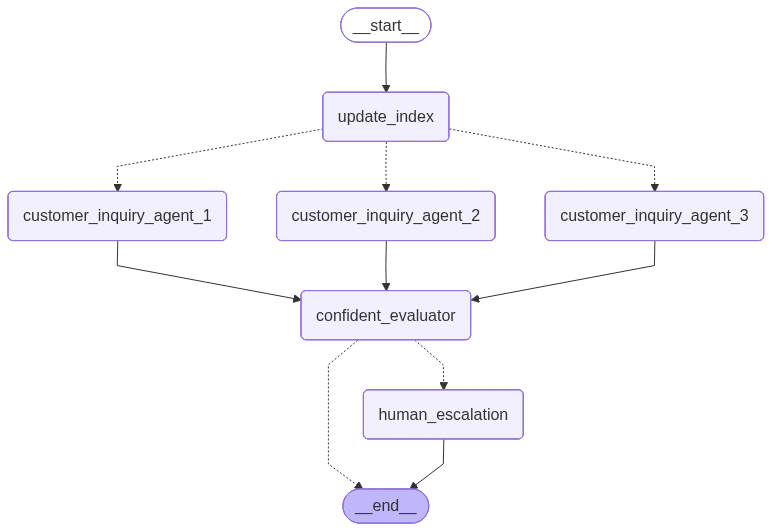

In [99]:
team_name = 'general_inquiry_team'
display(
    Image(
        agent_teams[team_name].get_graph().draw_mermaid_png()
    )
)

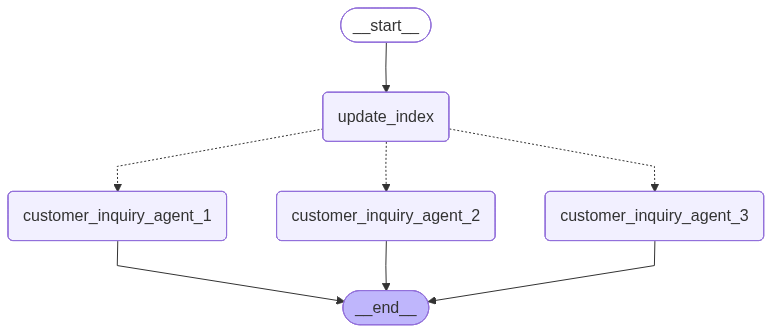

In [98]:
team_name = 'customer_inquiry_team'
display(
    Image(
        agent_teams[team_name].get_graph().draw_mermaid_png()
    )
)

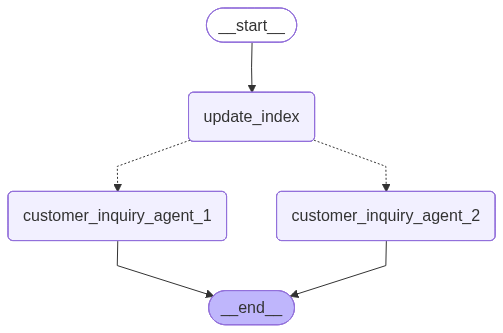

In [100]:
team_name = 'account_access_team'
display(
    Image(
        agent_teams[team_name].get_graph().draw_mermaid_png()
    )
)

## State Graph Definition

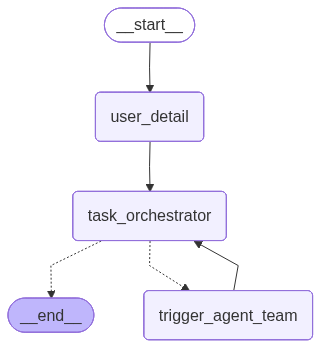

In [103]:
workflow = StateGraph(TicketProcessingState)

workflow.add_node("user_detail", user_detail_node)
workflow.add_node("task_orchestrator", task_orchestrator_node)
workflow.add_node("trigger_agent_team", trigger_agent_team_node)

workflow.add_edge(START, "user_detail")
workflow.add_edge("user_detail", "task_orchestrator")
workflow.add_edge("trigger_agent_team", "task_orchestrator")

checkpointer = MemorySaver()
ticket_processing_graph = workflow.compile(checkpointer=checkpointer)

display(
    Image(
        ticket_processing_graph.get_graph().draw_mermaid_png()
    )
)

# Main Graph

In [ ]:
config = {
    "configurable": {
        "thread_id": "Test_run",
        "agent_teams": agent_teams,
        "agent_swarm_map": agent_swarm_map,
        "recursion_limit": 100,
    }
}
tool_name = "get_highest_urgency_ticket"
response = await call_tool(all_tools, tool_name)
ticket = response['ticket']
ticket_content = ticket['ticket_content']
print(f"Ticket: {ticket_content}")
response = await ticket_processing_graph.ainvoke(input={"messages": "Start processing tickets.", **ticket}, config=config)
response_content = response["messages"][-1].content
response_content

In [ ]:
config = {
    "configurable": {
        "thread_id": "Test_run",
        "agent_teams": agent_teams,
        "agent_swarm_map": agent_swarm_map,
        "recursion_limit": 100,
    }
}
tool_name = "get_highest_urgency_ticket"
response = await call_tool(all_tools, tool_name)
ticket = response['ticket']
ticket_content = ticket['ticket_content']
print(f"Ticket: {ticket_content}")
response = await ticket_processing_graph.ainvoke(input={"messages": "Start processing tickets.", **ticket}, config=config)
response_content = response["messages"][-1].content
response_content

In [ ]:
tool_name = "delete_ticket"
_ = await call_tool(all_tools, tool_name, {"ticket_id": ticket['ticket_id']})

In [ ]:
ticket['ticket_id']

In [ ]:
async def process_ticket():
    print("Processing tickets from Udahub database...")
    # Get Ticket by Calling MCP Tool Manually
    tool_name = "get_highest_urgency_ticket"
    ticket_response = await call_tool(all_tools, tool_name)
    ticket = ticket_response['ticket']
    ticket_content = ticket["ticket_content"]
    print(f"Ticket: {ticket_content}")
    if not ticket:
        print("<There is no more tickets in the queue to process.>")
        success = False
    else:
        process_response = await ticket_processing_graph.ainvoke(input={"messages": "Start processing tickets."}, config=config)
        response_content = process_response["messages"][-1].content
        print(f"AI: {response_content}")
        # Delete ticket after processing
        # tool_name = "delete_ticket"
        # _ = await call_tool(all_tools, tool_name, {"ticket_id": ticket['ticket_id']})
        success = True
    return success

In [ ]:
config = {
    "configurable": {
        "thread_id": "Test_run",
        "agent_teams": agent_teams,
        "agent_swarm_map": agent_swarm_map,
        "recursion_limit": 100,
    }
}

async def process_ticket():
    print("Processing tickets from Udahub database...")
    # Get Ticket by Calling MCP Tool Manually
    tool_name = "get_highest_urgency_ticket"
    ticket_response = await call_tool(all_tools, tool_name)
    ticket = ticket_response['ticket']
    
    # For display
    ticket_content = ticket["ticket_content"]
    print(f"Ticket: {ticket_content}")
    
    if not ticket:
        print("There is no more tickets in the queue to process.")
        success = False
    else:
        process_response = await ticket_processing_graph.ainvoke(input={"messages": "Start processing tickets.", **ticket}, config=config)
        response_content = process_response["messages"][-1].content
        new_status = process_response["new_status"]
        print(f"AI: {response_content}")
        # Delete ticket after processing
        success = True
    return success

async def run():
    '''
    Main Routine of Chatbot
    '''
    user_id = input("Please enter your User ID: ").strip().lower()
    if not user_id:
        user_id = "default_user"
    
    print('''
          Welcome to ChatService, you have the following options:
                (1) Type 'quit' or 'exit' if you want to leave anytime.
                (2) Press ENTER without any input to process the next ticket in the queue.
                (3) Type 'all' to process all tickets in the queue.
                (4) Type your query directly to get response from the chatbot.
          ''')
    print("Please type your question:")

    while True:
        try:
            user_input = input(">> ").strip().lower()
            if user_input in ["quit", "exit"]:
                print("Exiting...")
                break
            elif len(user_input) == 0:
                _ = await process_ticket()
            elif user_input == "all":
                while True:
                    success = await process_ticket()
                    if success == False:
                        break
            else:
                input = {
                    "messages": "Start processing ticket.",
                    "user_id": user_id,
                    "ticket_content": user_input,
                    "ticket_id": "live_session",
                    "ticket_channel": "live_chatbot",
                    "ticket_urgency": 1,
                }
                result = await ticket_processing_graph.ainvoke(input=input, config=config)
                print(result.message.content)
        except KeyboardInterrupt:
            print("Exiting...")
            break

In [ ]:
await run()

# Testing Code

In [ ]:
tool_name = "get_highest_urgency_ticket"
ticket = await call_tool(all_tools, tool_name)
ticket['ticket']

In [ ]:
tavily_tool = TavilySearch(max_results=3, api_key=TAVILY_API_KEY)
await tavily_tool.ainvoke({'query': "What's the latest LangGraph version?"})

In [ ]:
print(f"Ticket content: {test_output_2.ticket_content}")
test_output_3 = await task_orchestrator_agent.ainvoke({"messages": [{"role": "system", "content": f"ticket_content: {test_output_2.ticket_content}"}]})
test_output_3['structured_response'].team

test_output_3 = await task_orchestrator_router(test_output_2)
test_output_3

In [ ]:
# --- Testing ---
prompt = PromptTemplate.from_template("Here is the customer inquiry ticket content: \n\n{ticket_content}. ")
formatted_prompt = prompt.format(ticket_content=test_output_2.ticket_content)
retrieval_messages = {"messages": [{"role": "system", "content": formatted_prompt}]}

response = await customer_inquiry_team_agent.ainvoke(retrieval_messages)
response['ticket_processed'] = True
response.keys()

In [ ]:
# --- Testing ---
prompt = PromptTemplate.from_template("Here is the customer inquiry ticket content: \n\n{ticket_content}. ")
formatted_prompt = prompt.format(ticket_content=test_output_2.ticket_content)
retrieval_messages = {"messages": [{"role": "system", "content": formatted_prompt}]}

response = await account_access_team_agent.ainvoke(retrieval_messages)
response['ticket_processed'] = True
response

In [ ]:
# --- Testing ---
prompt = PromptTemplate.from_template("Here is the customer inquiry ticket content: \n\n{ticket_content}. ")
formatted_prompt = prompt.format(ticket_content=test_output_2.ticket_content)
retrieval_messages = {"messages": [{"role": "system", "content": formatted_prompt}]}

response = await general_inquiry_team_agent.ainvoke(retrieval_messages)
response['ticket_processed'] = True
response

In [ ]:
test_output_2.ticket_content

In [ ]:
user_id = '3ca997'
user_id = 'cf5b19'
user_id = 'a4ab87'
tool_name = "get_user_subscription_details"
user_detail = await call_tool(all_tools, tool_name, {"user_id": user_id})
user_detail

In [ ]:
tool_name = "get_highest_urgency_ticket"
query = {}
my_tool = next(tool for tool in all_tools if tool.name == tool_name)
result = await my_tool.ainvoke(query)
raw_text = result[0]["text"]
parsed = json.loads(raw_text)
parsed['ticket']

In [ ]:
tool_name = "get_highest_urgency_ticket"
query = {}
my_tool = next(tool for tool in all_tools if tool.name == tool_name)
result = await my_tool.ainvoke(query)
raw_text = result[0]["text"]
parsed = json.loads(raw_text)
parsed

In [ ]:
tool_name = "get_highest_urgency_ticket"
ticket = await call_tool(all_tools, tool_name)
ticket

In [ ]:
tool_name = "web_search"
query = "What is the refund policy for cancellations?"
result = await call_tool(all_tools, tool_name, query)
result

In [ ]:
from sqlalchemy import create_engine, text
from typing import List, Dict, Any, Optional

UDAHUB_DB_PATH = os.getenv("UDAHUB_DB_PATH", "data/core/udahub.db")
DB_URL = 'sqlite:///data/core/udahub.db'
engine = create_engine(DB_URL)

def get_highest_urgency_ticket() -> Optional[Dict[str, Any]]:
    """
    Fetches the ticket with the highest urgency score using raw SQL.
    """
    query = text("""
        SELECT 
            t.ticket_id, 
            tm.content, 
            u.external_user_id AS owner_id, 
            t.channel, 
            tmd.tags, 
            t.account_id, 
            tmd.urgency_score
        FROM tickets t
        JOIN ticket_metadata tmd ON t.ticket_id = tmd.ticket_id
        JOIN users u ON t.user_id = u.user_id
        JOIN ticket_messages tm ON t.ticket_id = tm.ticket_id
        ORDER BY tmd.urgency_score DESC
        LIMIT 1
    """)

    with engine.connect() as conn:
        result = conn.execute(query).mappings().first()
        
        if not result:
            return None
            # return {"error": "User or subscription not found."}
        else:
            result = dict(result)
            result["user_id"] = result.pop("owner_id")
            result["account_id"] = result.pop("account_id")
            result["ticket_content"] = result.pop("content")
            result["ticket_tag"] = bool(result.pop("tags"))
            result["ticket_channel"] = result.pop("channel")
            result["ticket_urgency"] = result.pop("urgency_score")
            return result

In [ ]:
class HighestUrgencyTicket(TypedDict, total=False):     # `total=False`: None of these keys are strictly required
    ticket_id: str
    user_id: str
    account_id: str
    ticket_content: str
    ticket_tag: str
    ticket_channel: str
    ticket_urgency: float

def get_highest_urgency_ticket() -> HighestUrgencyTicket:
    """
    Fetches the ticket with the highest urgency score using raw SQL.
    """
    query = text("""
        SELECT 
            t.ticket_id, 
            tm.content, 
            u.external_user_id AS owner_id, 
            t.channel, 
            tmd.tags, 
            t.account_id, 
            tmd.urgency_score
        FROM tickets t
        JOIN ticket_metadata tmd ON t.ticket_id = tmd.ticket_id
        JOIN users u ON t.user_id = u.user_id
        JOIN ticket_messages tm ON t.ticket_id = tm.ticket_id
        ORDER BY tmd.urgency_score DESC
        LIMIT 1
    """)

    try:
        with engine.connect() as conn:
            result = conn.execute(query).mappings().first()
            if result is None:
                result = HighestUrgencyTicket({})
            else:
                result = dict(result)
                result["user_id"] = result.pop("owner_id")
                result["account_id"] = result.pop("account_id")
                result["ticket_id"] = result.pop("ticket_id")
                result["ticket_content"] = result.pop("content")
                result["ticket_tag"] = result.pop("tags")
                result["ticket_channel"] = result.pop("channel")
                result["ticket_urgency"] = result.pop("urgency_score")
                result = HighestUrgencyTicket(result)
    except Exception as e:
        print('exception')
        result = HighestUrgencyTicket({})
    return result

In [ ]:
out = get_highest_urgency_ticket()
out

In [ ]:
from sqlalchemy import create_engine, text
from typing import List, Dict, Any

DB_URL = f"sqlite:///{CULTPASS_DB_PATH}"
engine = create_engine(DB_URL)
def get_user_subscription_details(user_id: str) -> Dict[str, Any]:
    """
    Returns the user's subscription status and tier using direct engine execution.
    """
    sql = text("""
        SELECT u.full_name, u.is_blocked, u.email, s.status, s.tier 
        FROM users u
        JOIN subscriptions s ON u.user_id = s.user_id
        WHERE u.user_id = :user_id
    """)
    
    with engine.connect() as conn:
        result = conn.execute(sql, {"user_id": user_id}).mappings().first()
        
        if not result:
            return None
            # return {"error": "User or subscription not found."}
        else:
            result = dict(result)
            result["user_name"] = result.pop("full_name")
            result["user_status"] = result.pop("status")
            result["user_tier"] = result.pop("tier")
            result["user_is_blocked"] = bool(result.pop("is_blocked"))
            result["user_email"] = result.pop("email")
            return result

In [ ]:
out = get_user_subscription_details("888fb2")
out

In [ ]:
out = get_user_subscription_details('3ca997')
out

In [ ]:
from tavily import TavilyClient
import datetime

def web_search(query: str, search_depth: int = "basic") -> dict:
    """
    Search the web using Tavily API
    args:
        query (str): Search query
        search_depth (str): Type of search - 'basic' or 'advanced' (default: advanced)
    """
    client = TavilyClient(api_key=TAVILY_API_KEY)
    
    # Perform the search
    search_result = client.search(
        query=query,
        search_depth=search_depth,
        include_answer=True,
        include_raw_content=False,
        include_images=False
    )
    
    # Format the results
    formatted_results = {
        "answer": search_result.get("answer", "No direct answer found."),
        "results": [
            {"title": r["title"], "url": r["url"], "content": r["content"]} 
            for r in search_result.get("results", [])
        ],
        "metadata": {
            "timestamp": datetime.datetime.now().isoformat(),
            "query": query
        }
    }
    return formatted_results

In [ ]:
web_search("What is the refund policy for cancellations?")